In [10]:
#Project to build 
#An end-to-end deep learning system that can predict where someone is standing inside a building using only the WiFi signals their device detects.


#Project Member: Shaeekh Al Jahan
#Declarion of AI: Took help from GPT to generate graphs and format descriptions

"""
3.1 - Loads tensors, phase2_config.json and coord_scaler.pkl from the notebook directory ('.').
3.2 - Rebuilding model using IndoorLocMLp, coming from saved config
3.3 - Training loaders, batch size 256 is configured
3.4 - Similar setup from phase 2 for loss, optimiser and scheduler
3.5 Training Loop/ Prints a table every epoch. Saves best_model.pt. Stops if no improvement for 10 epochs
3.6 - Two Learning curves side by side to visualize train vs validation loss. Also, timing of scheduler
3.7 - Euclidean error in meters
3.8 - Error plots along with true vs predicted scatter plot of positions

"""

"\n3.1 - Loads tensors, phase2_config.json and coord_scaler.pkl from the notebook directory ('.').\n3.2 - Rebuilding model using IndoorLocMLp, coming from saved config\n3.3 - Training loaders, batch size 256 is configured\n3.4 - Similar setup from phase 2 for loss, optimiser and scheduler\n3.5 Training Loop/ Prints a table every epoch. Saves best_model.pt. Stops if no improvement for 10 epochs\n3.6 - Two Learning curves side by side to visualize train vs validation loss. Also, timing of scheduler\n3.7 - Euclidean error in meters\n3.8 - Error plots along with true vs predicted scatter plot of positions\n\n"

# UJIIndoorLoc — Phase 3: Training & Hyperparameter Tuning

**Goal:** Train the MLP defined in Phase 2, monitor learning curves, apply early stopping, and save the best model checkpoint.

**Inputs (from Phase 2):**
- `X_train.pt`, `y_train.pt`, `X_val.pt`, `y_val.pt`
- `coord_scaler.pkl` — for converting predictions back to metres
- `phase2_config.json` — model hyperparameters

**Deliverable:** `best_model.pt` + loss curves + Euclidean error on validation set

---
## 3.0  Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import time
from torch.utils.data import TensorDataset, DataLoader

print(f'PyTorch version : {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 2.9.1+cpu
Using device    : cpu


---
## 3.1  Load Phase 1 & 2 Outputs

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Point this to the folder where your .pt files and config live
BASE_PATH = '.'

X_train = torch.load(f'{BASE_PATH}/X_train.pt')
y_train = torch.load(f'{BASE_PATH}/y_train.pt')
X_val   = torch.load(f'{BASE_PATH}/X_val.pt')
y_val   = torch.load(f'{BASE_PATH}/y_val.pt')

with open(f'{BASE_PATH}/phase2_config.json') as f:
    config = json.load(f)

with open(f'{BASE_PATH}/coord_scaler.pkl', 'rb') as f:
    coord_scaler = pickle.load(f)

print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_val   : {y_val.shape}')
print(f'Config  : {config}')

X_train : torch.Size([19937, 465])
y_train : torch.Size([19937, 2])
X_val   : torch.Size([1111, 465])
y_val   : torch.Size([1111, 2])
Config  : {'input_dim': 465, 'hidden1': 512, 'hidden2': 256, 'dropout_p': 0.3, 'output_dim': 2, 'batch_size': 256, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'device': 'cpu'}


---
## 3.2  Rebuild Model (same architecture as Phase 2)

In [3]:
class IndoorLocMLP(nn.Module):
    def __init__(self, input_dim=465, hidden1=512, hidden2=256, dropout_p=0.3, output_dim=2):
        super(IndoorLocMLP, self).__init__()
        self.block1 = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        )
        self.output_layer = nn.Linear(hidden2, output_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.output_layer(x)

# ── Instantiate with config values ────────────────────────────────────────────
model = IndoorLocMLP(
    input_dim  = config['input_dim'],
    hidden1    = config['hidden1'],
    hidden2    = config['hidden2'],
    dropout_p  = config['dropout_p'],
    output_dim = config['output_dim']
).to(DEVICE)

print('Model ready.')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model ready.
Parameters: 371,970


---
## 3.3  DataLoaders

In [4]:
BATCH_SIZE = config['batch_size']

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 78
Val batches   : 5


---
## 3.4  Loss, Optimiser & Scheduler

In [5]:
criterion = nn.MSELoss()

optimiser = torch.optim.Adam(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='min',
    factor=0.5,
    patience=5
)

print('Loss, optimiser, scheduler ready.')

Loss, optimiser, scheduler ready.


---
## 3.5  Training Loop

### What happens each epoch
1. **Train phase** — model sees all batches, weights updated via backprop
2. **Val phase** — model frozen (`model.eval()`), no weight updates, just measure loss
3. **Scheduler step** — if val loss hasn't improved for 5 epochs, LR is halved
4. **Early stopping** — if val loss hasn't improved for 10 epochs, training stops
5. **Checkpoint** — whenever val loss hits a new best, save `best_model.pt`

In [6]:
# ── Training hyperparameters ──────────────────────────────────────────────────
NUM_EPOCHS     = 150
EARLY_STOP_PAT = 10      # stop if val loss doesn't improve for 10 epochs
CHECKPOINT     = f'{BASE_PATH}/best_model.pt'

# ── Tracking ──────────────────────────────────────────────────────────────────
train_losses = []
val_losses   = []
lr_history   = []

best_val_loss   = float('inf')
epochs_no_improve = 0

print(f'Training for up to {NUM_EPOCHS} epochs (early stop patience={EARLY_STOP_PAT})')
print(f'Batch size: {BATCH_SIZE}  |  Device: {DEVICE}')
print('-' * 65)
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>12}  {"LR":>10}  {"Time":>6}')
print('-' * 65)

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimiser.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_running_loss += loss.item() * xb.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)

    # ── Scheduler ─────────────────────────────────────────────────────────────
    scheduler.step(val_loss)
    current_lr = optimiser.param_groups[0]['lr']

    # ── Record ────────────────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    epoch_time = time.time() - epoch_start

    # ── Checkpoint ────────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        flag = '  ← best'
    else:
        epochs_no_improve += 1
        flag = ''

    # ── Log every epoch ───────────────────────────────────────────────────────
    print(f'{epoch:>6}  {train_loss:>12.6f}  {val_loss:>12.6f}  {current_lr:>10.6f}  {epoch_time:>5.1f}s{flag}')

    # ── Early stopping ────────────────────────────────────────────────────────
    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP_PAT} epochs)')
        break

total_time = time.time() - total_start
print('-' * 65)
print(f'Training complete in {total_time/60:.1f} min')
print(f'Best val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {CHECKPOINT}')

Training for up to 150 epochs (early stop patience=10)
Batch size: 256  |  Device: cpu
-----------------------------------------------------------------
 Epoch    Train Loss      Val Loss          LR    Time
-----------------------------------------------------------------
     1      0.589085      0.040050    0.001000    3.6s  ← best
     2      0.218138      0.025443    0.001000    3.5s  ← best
     3      0.107822      0.014185    0.001000    3.4s  ← best
     4      0.060375      0.013954    0.001000    3.3s  ← best
     5      0.036629      0.009179    0.001000    3.4s  ← best
     6      0.027741      0.010200    0.001000    3.4s
     7      0.020263      0.009011    0.001000    3.4s  ← best
     8      0.016298      0.007389    0.001000    3.4s  ← best
     9      0.013139      0.008570    0.001000    3.5s
    10      0.011556      0.007357    0.001000    3.4s  ← best
    11      0.010062      0.007096    0.001000    3.4s  ← best
    12      0.009106      0.005281    0.001000   

---
## 3.6  Learning Curves

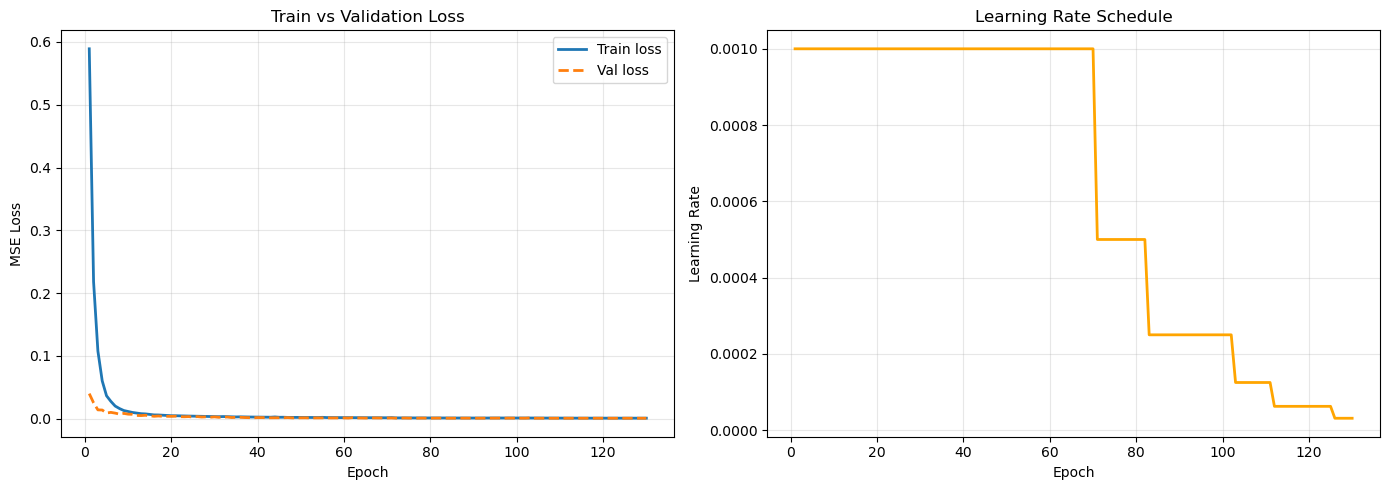

Saved: learning_curves.png


In [7]:
epochs_ran = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curves ───────────────────────────────────────────────────────────────
axes[0].plot(range(1, epochs_ran+1), train_losses, label='Train loss', linewidth=2)
axes[0].plot(range(1, epochs_ran+1), val_losses,   label='Val loss',   linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── LR history ────────────────────────────────────────────────────────────────
axes[1].plot(range(1, epochs_ran+1), lr_history, color='orange', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')

---
## 3.7  Evaluate on Validation Set (Euclidean Distance in Metres)

Load the best checkpoint and compute the primary metric — mean Euclidean error in real-world metres.

In [8]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

# ── Collect all predictions ───────────────────────────────────────────────────
all_preds  = []
all_targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        pred = model(xb)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(yb.numpy())

preds   = np.vstack(all_preds)    # (1111, 2) — normalised
targets = np.vstack(all_targets)  # (1111, 2) — normalised

# ── Inverse transform to real-world coordinates ───────────────────────────────
preds_real   = coord_scaler.inverse_transform(preds)
targets_real = coord_scaler.inverse_transform(targets)

# ── Euclidean distance per sample ─────────────────────────────────────────────
errors = np.sqrt(
    (preds_real[:, 0] - targets_real[:, 0])**2 +
    (preds_real[:, 1] - targets_real[:, 1])**2
)

print('=' * 45)
print('  Validation Set — Euclidean Error (metres)')
print('=' * 45)
print(f'  Mean error   : {errors.mean():.2f} m')
print(f'  Median error : {np.median(errors):.2f} m')
print(f'  Std deviation: {errors.std():.2f} m')
print(f'  Min error    : {errors.min():.2f} m')
print(f'  Max error    : {errors.max():.2f} m')
print(f'  % under 10m  : {(errors < 10).mean()*100:.1f}%')
print(f'  % under 20m  : {(errors < 20).mean()*100:.1f}%')
print('=' * 45)

  Validation Set — Euclidean Error (metres)
  Mean error   : 9.73 m
  Median error : 7.30 m
  Std deviation: 9.30 m
  Min error    : 0.04 m
  Max error    : 116.40 m
  % under 10m  : 64.9%
  % under 20m  : 91.6%


---
## 3.8  Error Distribution Plot

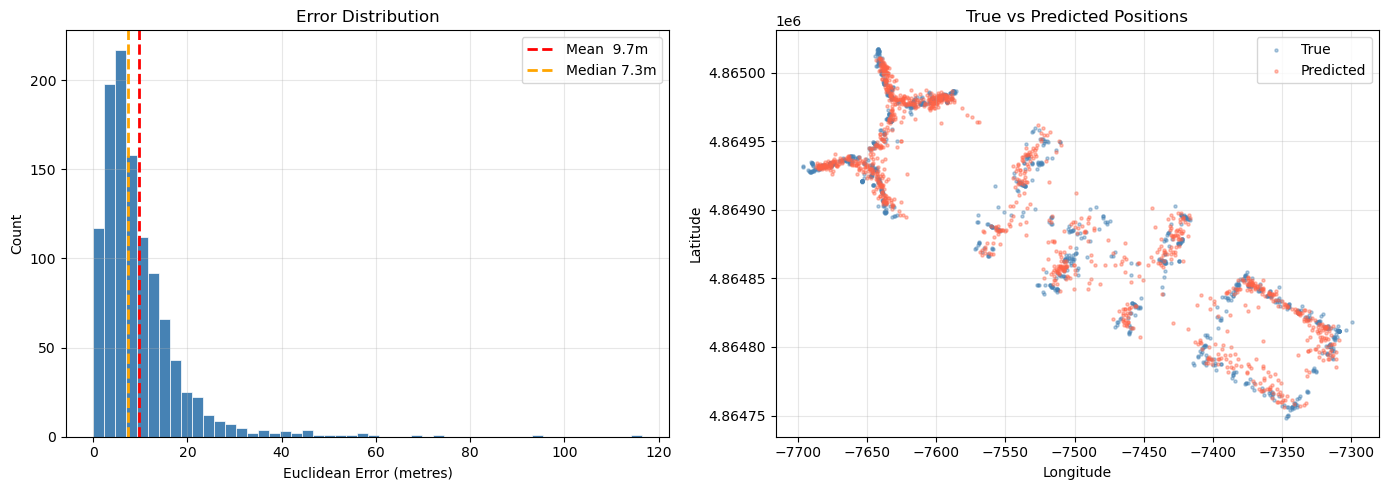

Saved: error_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram ─────────────────────────────────────────────────────────────────
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(errors.mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean  {errors.mean():.1f}m')
axes[0].axvline(np.median(errors), color='orange', linestyle='--', linewidth=2, label=f'Median {np.median(errors):.1f}m')
axes[0].set_xlabel('Euclidean Error (metres)')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Predicted vs True scatter ──────────────────────────────────────────────────
axes[1].scatter(targets_real[:, 0], targets_real[:, 1],
                s=5, alpha=0.4, label='True',      color='steelblue')
axes[1].scatter(preds_real[:, 0],   preds_real[:, 1],
                s=5, alpha=0.4, label='Predicted', color='tomato')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('True vs Predicted Positions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_distribution.png')

---
## 3.9  Phase 3 Summary

| Metric | Value |
|---|---|
| Best val MSE loss | *(from training)* |
| Mean Euclidean error | *(metres — from 3.7)* |
| Checkpoint saved | `best_model.pt` |
| Learning curves saved | `learning_curves.png` |
| Error plots saved | `error_distribution.png` |

### What's next — Phase 4
- Per-floor and per-building error breakdown
- Predicted vs true coordinate scatter plots with floor overlays
- Full evaluation report
- Stretch goal: LSTM temporal model for trajectory prediction